# Mini Project: Exploratory Data Analysis on India's COVID-19 Data

## Introduction

The COVID-19 pandemic significantly impacted India's healthcare system and population. This project aims to analyze COVID-19 cases and vaccination data using Python libraries such as NumPy, Pandas, Matplotlib, and Seaborn.

## Objectives

* Analyze state-wise COVID-19 confirmed cases, recoveries, and deaths.
* Explore daily trends in COVID-19 cases.
* Compare the spread of COVID-19 across Indian states.
* Analyze India's vaccination progress.
* Visualize meaningful patterns and trends in the data.


### 1. Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


### 2. Load the Data

In [3]:
url = "https://raw.githubusercontent.com/imdevskp/covid-19-india-data/master/complete.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")

Dataset loaded successfully!


### 3. Inspect Data Before Modification

In [6]:
df.head()
print("Dataset Shape:", df.shape)
print("\nColumn Name")
print(df.columns.to_list())

Dataset Shape: (4692, 10)

Column Name
['Date', 'Name of State / UT', 'Latitude', 'Longitude', 'Total Confirmed cases', 'Death', 'Cured/Discharged/Migrated', 'New cases', 'New deaths', 'New recovered']


In [17]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4692 entries, 0 to 4691
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       4692 non-null   str    
 1   Name of State / UT         4692 non-null   str    
 2   Latitude                   4692 non-null   float64
 3   Longitude                  4692 non-null   float64
 4   Total Confirmed cases      4692 non-null   float64
 5   Death                      4692 non-null   str    
 6   Cured/Discharged/Migrated  4692 non-null   float64
 7   New cases                  4692 non-null   int64  
 8   New deaths                 4692 non-null   int64  
 9   New recovered              4692 non-null   int64  
dtypes: float64(4), int64(3), str(3)
memory usage: 366.7 KB


In [18]:
df.isnull().sum()

Date                         0
Name of State / UT           0
Latitude                     0
Longitude                    0
Total Confirmed cases        0
Death                        0
Cured/Discharged/Migrated    0
New cases                    0
New deaths                   0
New recovered                0
dtype: int64

In [19]:
df.describe()

,Latitude,Longitude,Total Confirmed cases,Cured/Discharged/Migrated,New cases,New deaths,New recovered
count,4692.000000,4692.000000,4692.000000,4692.000000,4692.000000,4692.0,4692.000000
mean,23.185327,81.451837,11393.925192,6908.130648,418.643009,0.0,283.069054
std,6.635913,6.959475,37208.600846,23390.671258,1259.748923,0.0,947.925811
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,-1.000000
25%,18.112400,76.271100,39.000000,9.000000,1.000000,0.0,0.000000
50%,23.940800,79.019300,619.000000,197.500000,26.000000,0.0,8.000000
75%,28.218000,85.313100,5233.000000,2736.000000,210.250000,0.0,119.000000
max,34.299600,94.727800,468265.000000,305521.000000,18366.000000,0.0,13401.000000


In [20]:
df.nunique()

Date                          186
Name of State / UT             40
Latitude                       36
Longitude                      32
Total Confirmed cases        2570
Death                         839
Cured/Discharged/Migrated    2143
New cases                    1058
New deaths                      1
New recovered                 901
dtype: int64

In [21]:
df['Death'].head()

0    0
1    0
2    0
3    0
4    0
Name: Death, dtype: str

In [22]:
df["Death"].unique()[:20]

<StringArray>
[ '0',  '1',  '2',  '3',  '4',  '5',  '6',  '8',  '9', '13',  '7', '16', '19',
 '10', '24', '11', '45', '12', '64', '72']
Length: 20, dtype: str

### 4. Clean the Data

In [ ]:
# 1. convert death into numeric dtype
df["Death"]=pd.to_numeric(df["Death"],errors="coerce")  
print(df['Death'].dtype)
print(df["Death"].head())

In [ ]:
# 2. convert Date into datetime format
df["Date"]=pd.to_datetime(df["Date"],errors="coerce") 
print(df["Date"].dtype)
print(df["Date"].head())

datetime64[us]
0   2020-01-30
1   2020-01-31
2   2020-02-01
3   2020-02-02
4   2020-02-03
Name: Date, dtype: datetime64[us]


In [ ]:
# 3. convert column name into readable names
df.columns=[ "date", "state", "lat", "long", "confirmed",        
    "deaths", "cured", "new_cases", "new_deaths", "new_recovered",]
print(df.columns.tolist())

['date', 'state', 'lat', 'long', 'confirmed', 'deaths', 'cured', 'new_cases', 'new_deaths', 'new_recovered']


In [ ]:
# 4. check for duplicate columns
df.duplicated().sum()


np.int64(0)

In [ ]:
# 5. check all unique columns
df["state"].unique()


<StringArray>
[                                  'Kerala',
                                    'Delhi',
                                'Telengana',
                                  'Haryana',
                                'Rajasthan',
                            'Uttar Pradesh',
                               'Tamil Nadu',
                'Union Territory of Ladakh',
                                'Karnataka',
                              'Maharashtra',
                                   'Punjab',
     'Union Territory of Jammu and Kashmir',
                           'Andhra Pradesh',
                              'Uttarakhand',
                                   'Odisha',
                               'Puducherry',
                              'West Bengal',
                             'Chhattisgarh',
            'Union Territory of Chandigarh',
                                  'Gujarat',
                               'Chandigarh',
                         'Himachal Prades

In [ ]:
#count and match with the length of unique states
df["state"].nunique()

40

In [55]:
# 6. Check for Negative Values
count_cols = [
    "confirmed",
    "deaths",
    "cured",
    "new_cases",
    "new_deaths",
    "new_recovered"
]

(df[count_cols] < 0).sum()

confirmed        0
deaths           0
cured            0
new_cases        0
new_deaths       0
new_recovered    3
dtype: int64

In [57]:
df[df["new_recovered"]<0]

,date,state,lat,long,confirmed,deaths,cured,new_cases,new_deaths,new_recovered
159,2020-03-15,Uttar Pradesh,26.8467,80.9462,13.0,0.0,4.0,1,0,-1
527,2020-04-01,Andhra Pradesh,15.9129,79.7400,83.0,0.0,0.0,43,0,-1
554,2020-04-02,Andaman and Nicobar Islands,11.7401,92.6586,10.0,0.0,0.0,0,0,-1


In [58]:
df.loc[df["new_recovered"] < 0, "new_recovered"]

159   -1
527   -1
554   -1
Name: new_recovered, dtype: int64

In [60]:
# 7. cleaning the negative value entries 
df.loc[df["new_recovered"]<0, "new_recovered"] = np.nan

In [64]:
#verify the cleaning
print((df[["new_recovered"]] < 0).sum())

new_recovered    0
dtype: int64


In [67]:
#check for missing values
df.isnull().sum()

date             0
state            0
lat              0
long             0
confirmed        0
deaths           1
cured            0
new_cases        0
new_deaths       0
new_recovered    3
dtype: int64

In [71]:
df[df.isnull().any(axis=1)]

,date,state,lat,long,confirmed,deaths,cured,new_cases,new_deaths,new_recovered
159,2020-03-15,Uttar Pradesh,26.8467,80.9462,13.0,0.0,4.0,1,0,NaN
527,2020-04-01,Andhra Pradesh,15.9129,79.7400,83.0,0.0,0.0,43,0,NaN
554,2020-04-02,Andaman and Nicobar Islands,11.7401,92.6586,10.0,0.0,0.0,0,0,NaN
2241,2020-05-24,Puducherry,11.9416,79.8083,26.0,NaN,10.0,0,0,0.0


In [ ]:
# 8. verify the data 
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

Dataset Shape: (4692, 10)

Missing Values:
date             0
state            0
lat              0
long             0
confirmed        0
deaths           1
cured            0
new_cases        0
new_deaths       0
new_recovered    3
dtype: int64

Total Missing Values: 4


In [81]:
# keep nan values as they are intotal only 4 so it doesn't affect our dataset
# 9. check data range
print("Start Date", df['date'].min())
print("Last Date", df['date'].max())
print("Unique Dates:", df["date"].nunique())

Start Date 2020-01-30 00:00:00
Last Date 2020-08-06 00:00:00
Unique Dates: 186


In [85]:
# 10. check number of unique states
print("unique state", df['state'].nunique())
print(sorted(df["state"].unique()))

unique state 40
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli and Daman and Diu', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Telangana***', 'Telengana', 'Tripura', 'Union Territory of Chandigarh', 'Union Territory of Jammu and Kashmir', 'Union Territory of Ladakh', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


### 5. State-wise Analysis of COVID-19 Confirmed Cases
CHART 1

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
df=df.sort_values("date")
latest_data=df.groupby("state").tail(1)
top_10=latest_data.nlargest(10,"confirmed")
top_10[["state", "confirmed"]]

,state,confirmed
4676,Maharashtra,468265.0
4686,Tamil Nadu,273460.0
4658,Andhra Pradesh,186461.0
4672,Karnataka,151449.0
4665,Delhi,140232.0
4689,Uttar Pradesh,104388.0
4691,West Bengal,83800.0
4687,Telangana,73050.0
4667,Gujarat,66669.0
4661,Bihar,64770.0


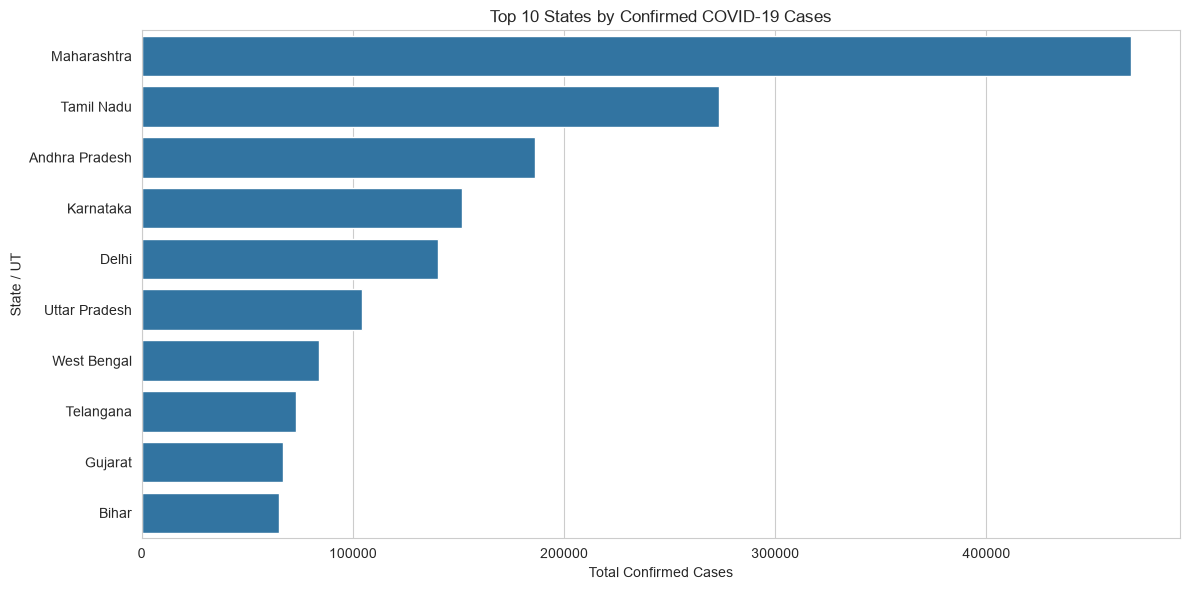

In [89]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_10,
    x="confirmed",
    y="state"
)
plt.title("Top 10 States by Confirmed COVID-19 Cases")
plt.xlabel("Total Confirmed Cases")
plt.ylabel("State / UT")
plt.tight_layout()
plt.show()

### Observation
The bar chart shows the 10 states/UTs with the highest recorded
COVID-19 deaths in the dataset. The states with longer bars
have higher reported death counts in their latest available records.

### 6. State-wise Analysis of COVID-19 Deaths CHART 2

In [93]:
top_10_deaths=latest_data.nlargest(10,"deaths")
top_10_deaths[["state","deaths"]]

,state,deaths
4676,Maharashtra,16476.0
4686,Tamil Nadu,4461.0
4665,Delhi,4044.0
4672,Karnataka,2804.0
4667,Gujarat,2556.0
4689,Uttar Pradesh,1857.0
4691,West Bengal,1846.0
4658,Andhra Pradesh,1681.0
4675,Madhya Pradesh,929.0
4684,Rajasthan,745.0


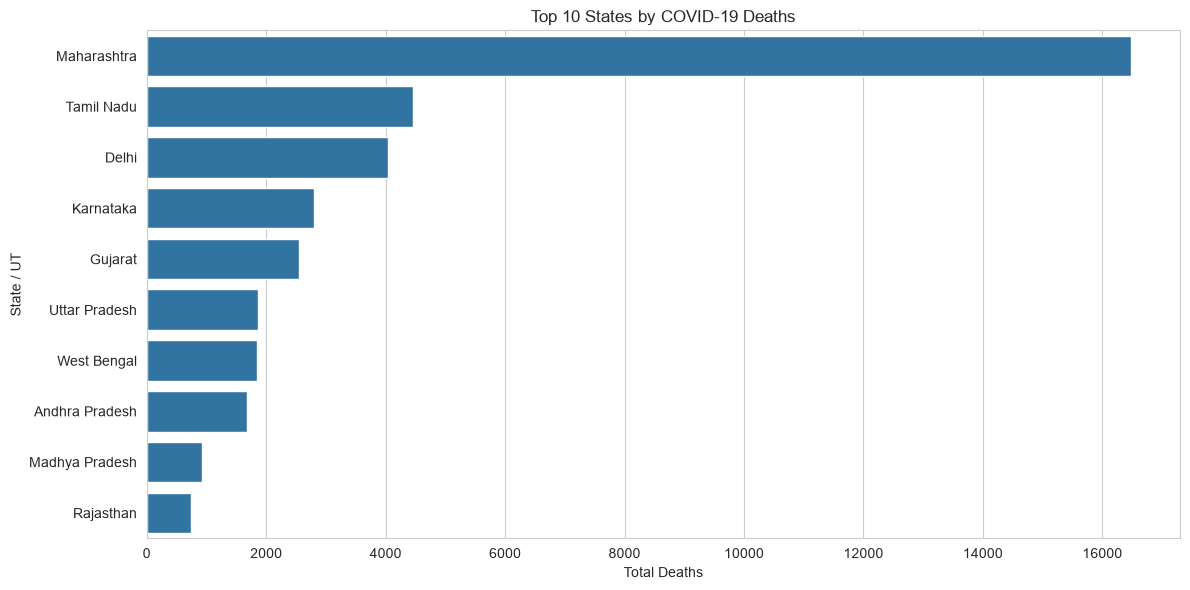

In [95]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_10_deaths,
    x="deaths",
    y="state"
)
plt.title("Top 10 States by COVID-19 Deaths")
plt.xlabel("Total Deaths")
plt.ylabel("State / UT")
plt.tight_layout()
plt.show()

### Observation
The bar chart displays the 10 states/UTs with the highest recorded COVID-19 deaths in the dataset. States with longer bars have higher reported death counts in their latest available records.

### 7. Daily Trend Analysis of COVID-19 Cases in India CHART 3

In [98]:
daily_cases=df.groupby("date")["new_cases"].sum().reset_index()
daily_cases.head()

,date,new_cases
0,2020-01-30,0
1,2020-01-31,0
2,2020-02-01,1
3,2020-02-02,1
4,2020-02-03,0


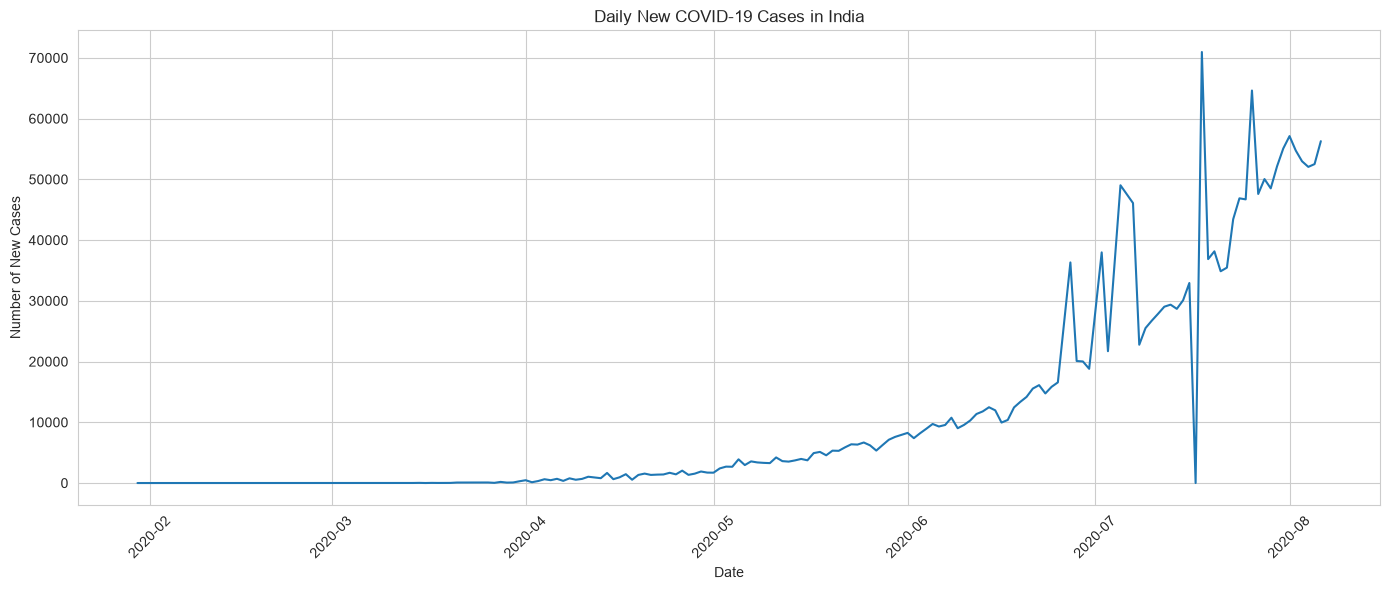

In [99]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=daily_cases,
    x="date",
    y="new_cases"
)

plt.title("Daily New COVID-19 Cases in India")
plt.xlabel("Date")
plt.ylabel("Number of New Cases")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation
The line chart illustrates the trend in daily reported COVID-19 cases in India over the dataset's time period. Peaks indicate dates with higher numbers of newly reported cases, while dips indicate lower reported counts.

### 8. Daily Trend Analysis of COVID-19 Deaths in India CHART4

In [118]:

daily_deaths = df.groupby("date")["deaths"].sum().reset_index()
daily_deaths.head()

,date,deaths
0,2020-01-30,0.0
1,2020-01-31,0.0
2,2020-02-01,0.0
3,2020-02-02,0.0
4,2020-02-03,0.0


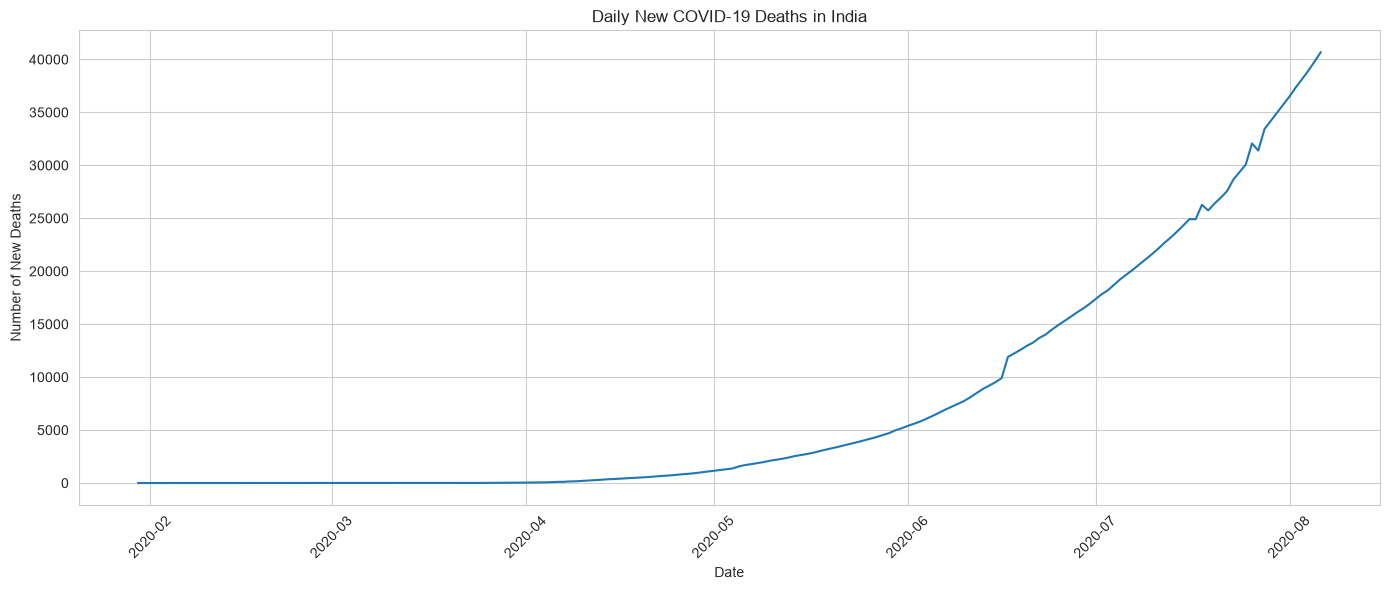

In [120]:

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=daily_deaths,
    x="date",
    y="deaths"
)

plt.title("Daily New COVID-19 Deaths in India")
plt.xlabel("Date")
plt.ylabel("Number of New Deaths")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observtion
The line chart shows the trend in cumulative reported COVID-19 deaths in India over the dataset's time period. The overall increase represents the accumulation of reported deaths over time.

### 9. State-wise Distribution of Confirmed Cases CHART 5 (PIE)

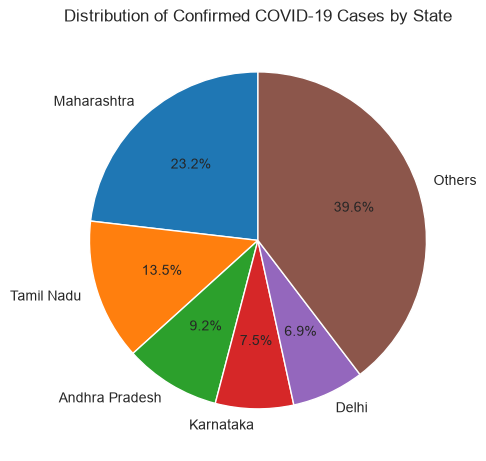

In [123]:

top_5 = latest_data.nlargest(5, "confirmed")

others = latest_data["confirmed"].sum() - top_5["confirmed"].sum()

labels = list(top_5["state"]) + ["Others"]
values = list(top_5["confirmed"]) + [others]
plt.figure(figsize=(5,5))

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Confirmed COVID-19 Cases by State")
plt.tight_layout()
plt.show()

### Observation
Which states account for the largest share of confirmed cases in the dataset's latest available state-wise records?

### 10.Correlation Heatmap — COVID-19 Variables CHART 6

In [124]:
corr_data = latest_data[
    ["confirmed", "deaths", "cured", "new_cases", "new_recovered"]
]
corr_matrix = corr_data.corr()
corr_matrix

,confirmed,deaths,cured,new_cases,new_recovered
confirmed,1.000000,0.926468,0.988088,0.885093,0.834465
deaths,0.926468,1.000000,0.914051,0.727713,0.611372
cured,0.988088,0.914051,1.000000,0.822328,0.781854
new_cases,0.885093,0.727713,0.822328,1.000000,0.967318
new_recovered,0.834465,0.611372,0.781854,0.967318,1.000000


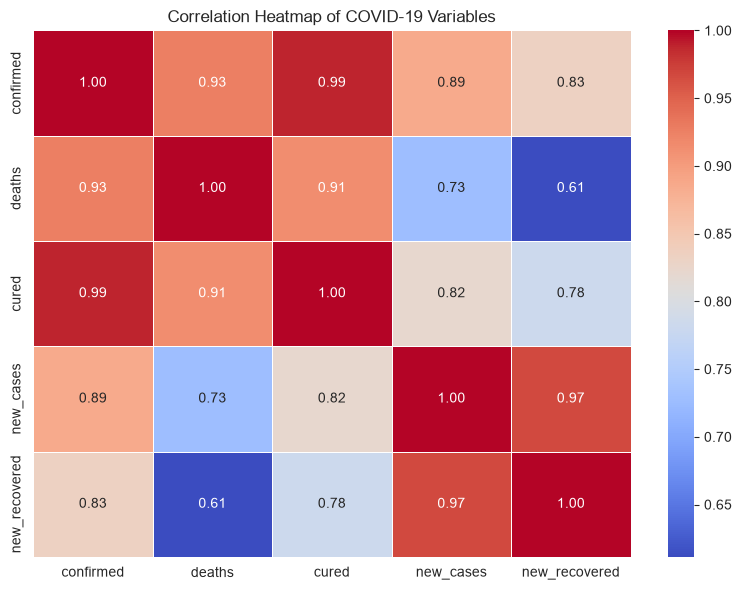

In [126]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of COVID-19 Variables")
plt.tight_layout()
plt.show()

### Observation
Close to +1 = Strong positive linear relationship
Close to 0 = Weak or no linear relationship
Close to -1 = Strong negative linear relationship

### 11. Scatter Plot — Confirmed Cases vs Deaths CHART 7

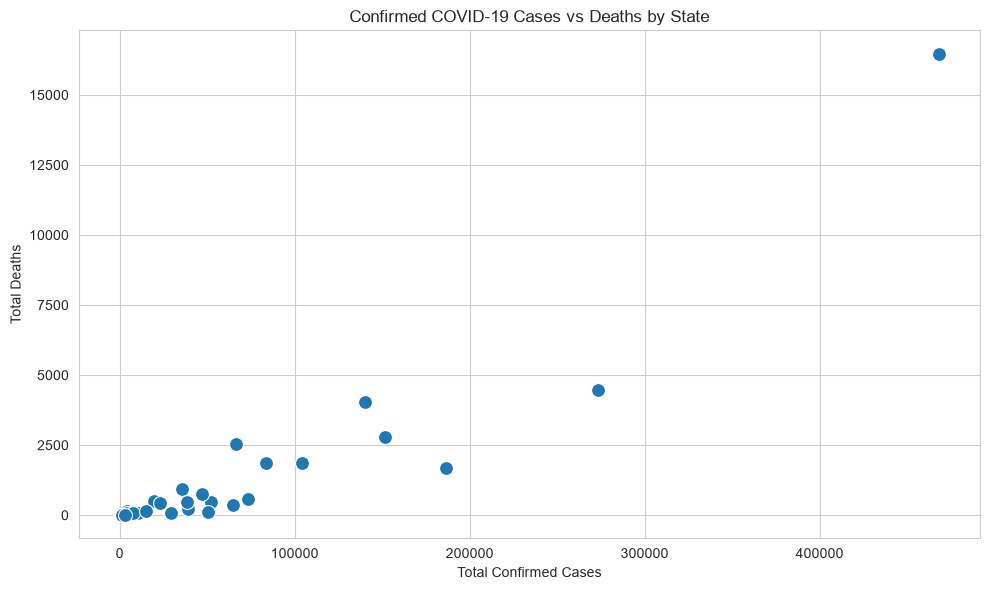

In [127]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=latest_data,
    x="confirmed",
    y="deaths",
    s=100
)

plt.title("Confirmed COVID-19 Cases vs Deaths by State")
plt.xlabel("Total Confirmed Cases")
plt.ylabel("Total Deaths")

plt.tight_layout()
plt.show()

### Observation
A general upward pattern indicates that states with more confirmed cases also tend to have more recorded deaths.

### 12. Save the Cleaned Dataset

In [128]:
df.to_csv("cleaned_covid_india.csv", index=False)
print("Saved cleaned_covid_india.csv -", df.shape[0], "rows.")

Saved cleaned_covid_india.csv - 4692 rows.


### 13. Written Summary

Dataset Overview. The dataset contains COVID-19 records across Indian states and union territories, covering the period from 30 January 2020 to 6 August 2020. It includes information on confirmed cases, deaths, recoveries, and daily reported cases, allowing us to explore the spread of COVID-19 during the early phase of the pandemic in India.


State-wise Distribution of Confirmed Cases. The state-wise analysis highlights differences in the number of confirmed COVID-19 cases across states and union territories. The top 10 states by confirmed cases help identify regions that accounted for a substantial share of the reported cases in the dataset.


State-wise Distribution of Deaths. The analysis of cumulative deaths shows variations in reported COVID-19 fatalities across states. Comparing state-wise death counts provides insight into how the impact of the pandemic differed geographically during the period covered by the dataset.


Daily COVID-19 Case Trends. The daily new-case trend illustrates how reported COVID-19 cases changed over time. The line chart shows an overall increase in reported cases during the dataset period, with fluctuations and peaks on particular dates.


Cumulative Death Trends. The cumulative-deaths visualization shows the accumulation of reported deaths over time. The overall upward trend reflects the growing number of recorded COVID-19 fatalities during the period under study.


Distribution and Correlation Analysis. The pie chart provides a visual representation of the share of confirmed cases across the top states and the remaining states combined. The correlation heatmap helps explore linear relationships among numerical COVID-19 variables, while the scatter plot illustrates the relationship between confirmed cases and cumulative deaths across states.


Data Quality and Limitations. During data cleaning, missing values and invalid negative values in the new-recovered column were identified and handled. The new-deaths column contained only zero values in the working dataset, so it was excluded from meaningful daily-death analysis. Consequently, cumulative deaths were used to examine death trends. The findings are limited to the dataset's coverage and should not be interpreted as current COVID-19 statistics.


Conclusion. This exploratory data analysis provides an overview of the geographical distribution and temporal progression of COVID-19 in India during the first several months of 2020. The visualizations help identify patterns in confirmed cases, recoveries, and cumulative deaths while demonstrating the importance of data cleaning and validation before drawing conclusions from a dataset.